In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

In [32]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-03-02 14:22:00--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 72.247.96.197, 2600:1405:8400:286::317f, 2600:1405:8400:28b::317f
Connecting to download.microsoft.com (download.microsoft.com)|72.247.96.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip.1’

kagglecatsanddogs_5 100%[===================>] 786.67M   100MB/s    in 12s     

2026-03-02 14:22:12 (64.9 MB/s) - ‘kagglecatsanddogs_5340.zip.1’ saved [824887076/824887076]



In [33]:
# !unzip /content/kagglecatsanddogs_5340.zip

"/content/PetImages/Cat/1.jpg"

In [34]:
tf.keras.utils.image_dataset_from_directory('/content/PetImages/')

Found 25000 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [35]:
cats_dogs_training_dataset =  tf.keras.utils.image_dataset_from_directory('/content/PetImages/',  label_mode="binary", labels="inferred")
cats_dogs_training_dataset

Found 25000 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [36]:
cats_dogs_training_dataset.class_names

['Cat', 'Dog']

In [42]:

import os

num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("/content/PetImages/", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            print("Fisier corupt:", fpath)
            os.remove(fpath)

print("Deleted %d images" % num_skipped)

Fisier corupt: /content/PetImages/Cat/8000.jpg
Fisier corupt: /content/PetImages/Cat/1098.jpg
Fisier corupt: /content/PetImages/Cat/11083.jpg
Fisier corupt: /content/PetImages/Cat/2569.jpg
Fisier corupt: /content/PetImages/Cat/2405.jpg
Fisier corupt: /content/PetImages/Cat/2753.jpg
Fisier corupt: /content/PetImages/Cat/1534.jpg
Fisier corupt: /content/PetImages/Cat/5077.jpg
Fisier corupt: /content/PetImages/Cat/6690.jpg
Fisier corupt: /content/PetImages/Cat/9086.jpg
Fisier corupt: /content/PetImages/Cat/3116.jpg
Fisier corupt: /content/PetImages/Cat/8832.jpg
Fisier corupt: /content/PetImages/Cat/11933.jpg
Fisier corupt: /content/PetImages/Cat/7046.jpg
Fisier corupt: /content/PetImages/Cat/4938.jpg
Fisier corupt: /content/PetImages/Cat/1267.jpg
Fisier corupt: /content/PetImages/Cat/2375.jpg
Fisier corupt: /content/PetImages/Cat/1151.jpg
Fisier corupt: /content/PetImages/Cat/7843.jpg
Fisier corupt: /content/PetImages/Cat/1937.jpg
Fisier corupt: /content/PetImages/Cat/11145.jpg
Fisier cor

In [44]:
cats_dogs_model = tf.keras.models.Sequential(
    [
        # Input shape depinde de cum arata imaginea
        tf.keras.layers.Input(shape=(256, 256, 3)),

        ## Rescalez imaginea de la 0..255 la maxim 0..1
        tf.keras.layers.Rescaling(scale=1./255),

        tf.keras.layers.Resizing(height=224, width=224),

        ## S-a inceput cu tanh, acum relu este varianta mai buna
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=6, activation="relu"),

        ## Cea mai buna practica este MaxPooling2D
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

          ## S-a inceput cu tanh, acum relu este varianta mai buna
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=6, activation="relu"),

        ## Cea mai buna practica este MaxPooling2D
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        # Architectura de fully connected
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')


    ]
)
cats_dogs_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [38]:
cats_dogs_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 6)    │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 17496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,239,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,240,243 (8.55 MB)

 Trainable params: 2,240,243 (8.55 MB)

 Non-trainable params: 0 (0.00 B)

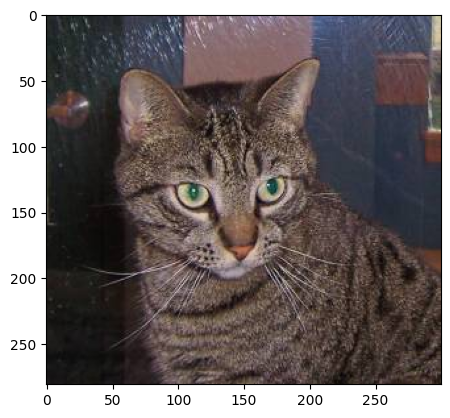

In [39]:
plt.imshow(plt.imread("/content/PetImages/Cat/1.jpg"))
#

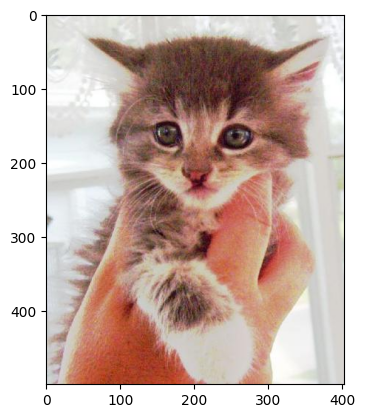

In [40]:
plt.imshow(plt.imread("/content/PetImages/Cat/100.jpg"))

In [45]:
cats_dogs_model.fit(cats_dogs_training_dataset, epochs=10, callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)])

Epoch 1/10


NotFoundError: Graph execution error:

Detected at node ReadFile defined at (most recent call last):
<stack traces unavailable>
/content/PetImages/Dog/11032.jpg; No such file or directory
	 [[{{node ReadFile}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_7794]